Assessment of Satellite-derived Building Datasets - Raster Dataset - World Bank - June 2026
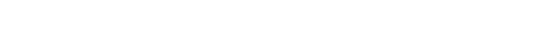


Overal Performance

In [ ]:
# ── Presentation palette & style ──────────────────────────────────────────────
FONT_FAMILY = 'Barlow, Barlow Semi Condensed, Arial, sans-serif'

DATASET_COLORS = {
    # Vector datasets
    'overture':            '#1B6CA8',
    'gba':                 '#2BAE82',
    'globfp':              '#66C7E0',
    # Raster — 10m resolution (solid fill/line)
    'wsf_tracker_10m':     '#C94A35',
    'obt_2023_10m':        '#E0882A',
    # Raster — 100m resolution (lighter fill, dashed line)
    'wsf_tracker_100m':    '#EFB3A9',
    'obt_2023_100m':       '#F5C98A',
    # Raster — unique 100m datasets
    'ghsl_built_s_2025':   '#CC2266',
    'tempo_2023q4':        '#7B4EBD',
}

DATASET_LABELS = {
    'overture':            'Overture Maps',
    'gba':                 'Google Open Buildings',
    'globfp':              'GlobFP',
    'ghsl_built_s_2025':   'GHSL 2025 (100m)',
    'tempo_2023q4':        'TEMPO Q4 2023 (100m)',
    'obt_2023':            'OBT 2023',
    'wsf_tracker':         'WSF Tracker',
    'wsf_tracker_10m':     'WSF Tracker (10m)',
    'wsf_tracker_100m':    'WSF Tracker (100m)',
    'obt_2023_10m':        'OBT 2023 (10m)',
    'obt_2023_100m':       'OBT 2023 (100m)',
}


def apply_ppt_style(fig):
    fig.update_layout(
        font=dict(family=FONT_FAMILY, size=14, color='#1a1a1a'),
        title_font=dict(size=20, family=FONT_FAMILY),
        legend=dict(
            font=dict(size=13),
            bgcolor='rgba(255,255,255,0.9)',
            bordercolor='#CCCCCC',
            borderwidth=1,
        ),
        plot_bgcolor='white',
        paper_bgcolor='white',
        margin=dict(t=80, b=60, l=70, r=30),
        width=1280,
        height=720,
    )
    fig.update_xaxes(
        title_font=dict(size=15),
        tickfont=dict(size=13),
        gridcolor='#E8E8E8',
        linecolor='#CCCCCC',
    )
    fig.update_yaxes(
        title_font=dict(size=15),
        tickfont=dict(size=13),
        gridcolor='#E8E8E8',
        linecolor='#CCCCCC',
    )
    return fig

In [13]:
!apt-get update -qq && apt-get install -y -qq libnss3 libatk-bridge2.0-0 libcups2 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libxkbcommon0 libpango-1.0-0 libcairo2 libasound2
!pip install -U plotly "kaleido>=1.0.0" -q
!plotly_get_chrome -y

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
import re, os

FONT_COLOR  = '#222222'
BG_COLOR    = 'white'
FONT_SIZE   = 16
print('Setup done')

from google.colab import files as _colab_files
import io as _io
print('Please upload raster_all_cities_merged.csv')
_uploaded = _colab_files.upload()
_fname = next(iter(_uploaded))
df_raw = pd.read_csv(_io.BytesIO(_uploaded[_fname]))
df_raw = df_raw.loc[:, ~df_raw.columns.duplicated()].copy()

def norm(c):
    s = re.sub(r'\s+', '_', str(c).strip().lower())
    s = re.sub(r'[^a-z0-9_]', '_', s)
    return re.sub(r'_+', '_', s).strip('_')
df_raw.columns = [norm(c) for c in df_raw.columns]
_raster_raw = df_raw.copy()  # save normalized raw for reuse in later cells

# Build working df using canonical column names
_keep = [c for c in [
    'city', 'dataset', 'grid', 'resolution_m', 'aoi_area_km2',
    'n_ref_buildings', 'ref_area_total_m2', 'pred_area_total_m2',
    'tp_total', 'fp_total', 'fn_total',
    'precision_area', 'recall_area', 'f1_area',
    'f1_tile_mean', 'f1_tile_median', 'tile_f1_p25', 'tile_f1_p75',
    'rel_area_error_mean', 'rel_area_error_median', 'signed_area_bias',
    'quantity_disagreement_mean', 'allocation_disagreement_mean',
    'buildings_per_km2', 'avg_building_size_m2',
] if c in df_raw.columns]
df = df_raw[_keep].copy()
df['city']    = df['city'].astype(str).str.strip()
df['dataset'] = df['dataset'].astype(str).str.strip().str.lower()
df['grid']    = df['grid'].astype(str).str.strip().str.lower()
for _c in [c for c in df.columns if c not in ('city','dataset','grid')]:
    df[_c] = pd.to_numeric(df[_c], errors='coerce')
df.reset_index(drop=True, inplace=True)

for _c in ['rel_area_error_mean','rel_area_error_median','signed_area_bias']:
    if _c in df.columns:
        df[_c] = df[_c].replace(-1, np.nan)

PREFERRED = [
    ('wsf_tracker','10m'),
    ('obt_2023','10m'),
    ('ghsl_built_s_2025','100m'),
    ('obt_2023','100m'),
    ('tempo_2023q4','100m'),
    ('wsf_tracker','100m'),
]
present = set(map(tuple, df[['dataset','grid']].drop_duplicates().values.tolist()))
KEEP = [combo for combo in PREFERRED if combo in present]
missing_combos = [c for c in PREFERRED if c not in present]
if missing_combos:
    print(f"NOTE: skipping missing combos -> {missing_combos}")
print(f"Using combos: {KEEP}")

df = df[df.apply(lambda r: (r['dataset'], r['grid']) in set(KEEP), axis=1)].copy()
df['ds_key'] = df['dataset'] + '@' + df['grid']
_raster_raw['ds_key'] = (_raster_raw['dataset'].astype(str).str.strip().str.lower()
                          + '@' + _raster_raw['grid'].astype(str).str.strip().str.lower())

# iou alias columns removed — use f1_tile_mean, f1_tile_median, tile_f1_p25, tile_f1_p75 directly

ORDER = [f"{d}@{g}" for d,g in PREFERRED]
# --- Zero-F1 city exclusion (item 8b) ---
# Exclude cities where ALL raster datasets report F1 = 0 (f1_tile_mean == 0 for all
# 6 ds_keys). These are coverage failures / pipeline errors, not genuine zero-accuracy
# results, and they distort the global means and error bars below. In-memory only;
# the excluded-city list is computed at runtime (no city names are hard-coded).
# Applied to both df and _raster_raw so the later cells inherit the exclusion.
RASTER_FILTER_DSKEYS = ['wsf_tracker@10m', 'obt_2023@10m', 'ghsl_built_s_2025@100m',
                        'tempo_2023q4@100m', 'wsf_tracker@100m', 'obt_2023@100m']
_rpiv = (df.drop_duplicates(['city', 'ds_key'])
           .pivot(index='city', columns='ds_key', values='f1_tile_mean')
           .reindex(columns=RASTER_FILTER_DSKEYS))
excluded_cities = sorted(_rpiv.index[(_rpiv == 0).all(axis=1)].tolist())
if excluded_cities:
    print(f'[item 8b] Excluding {len(excluded_cities)} cities (all datasets F1=0): {excluded_cities}')
else:
    print('[item 8b] No cities excluded (no city has all ds_keys F1=0).')
df = df[~df['city'].isin(excluded_cities)].reset_index(drop=True)
_raster_raw = _raster_raw[~_raster_raw['city'].astype(str).str.strip().isin(excluded_cities)].reset_index(drop=True)
_n_remaining = df['city'].nunique()
print(f'[item 8b] Raster cities remaining: {_n_remaining}')
all_datasets = [k for k in ORDER if k in df['ds_key'].unique().tolist()]

LABELS = {
    'wsf_tracker@10m'       : 'WSF-10m',
    'obt_2023@10m'          : 'OBT-10m',
    'ghsl_built_s_2025@100m': 'GHSL-100m',
    'obt_2023@100m'         : 'OBT-100m',
    'tempo_2023q4@100m'     : 'TEMPO-100m',
    'wsf_tracker@100m'      : 'WSF-100m',
}
dataset_labels = {k: LABELS[k] for k in all_datasets}

palette = [
    DATASET_COLORS.get(k, '#888888')
    for k in ['wsf_tracker_10m', 'obt_2023_10m', 'ghsl_built_s_2025', 'obt_2023_100m', 'tempo_2023q4', 'wsf_tracker_100m']
]
colors = {ds: palette[i % len(palette)] for i, ds in enumerate(all_datasets)}

base_layout = dict(
    font=dict(family=FONT_FAMILY, size=FONT_SIZE, color=FONT_COLOR),
    plot_bgcolor=BG_COLOR, paper_bgcolor=BG_COLOR,
    margin=dict(l=60, r=30, t=80, b=90),
    title_x=0.5, title_xanchor='center',
)

CENTER_LEGEND = dict(
    orientation='h', x=0.5, xanchor='center',
    y=-0.12, yanchor='top',
    bgcolor='rgba(255,255,255,0.9)',
    bordercolor='#CCCCCC', borderwidth=1,
    font=dict(size=13, family=FONT_FAMILY),
)

RES_GROUPS = {'all': list(all_datasets)}
RES_GROUPS = {res: ks for res, ks in RES_GROUPS.items() if ks}
print("Plot group (combined):", {r: [dataset_labels[k] for k in ks] for r, ks in RES_GROUPS.items()})

sums = df.groupby('ds_key').agg(
    n_rows   = ('city','count'),
    total_TP = ('tp_total','sum'),
    total_FP = ('fp_total','sum'),
    total_FN = ('fn_total','sum'),
).reindex(all_datasets).reset_index()

sums['precision'] = sums['total_TP'] / (sums['total_TP'] + sums['total_FP'])
sums['recall']    = sums['total_TP'] / (sums['total_TP'] + sums['total_FN'])
sums['f1']        = 2 * sums['precision'] * sums['recall'] / (sums['precision'] + sums['recall'])
sums['FP_FN_ratio'] = sums['total_FP'] / sums['total_FN'].replace(0, np.nan)

tile_mean = df.groupby('ds_key')['f1_tile_mean'].mean().reindex(all_datasets)
sums['f1_tile_mean'] = tile_mean.values
tile_sd = df.groupby('ds_key')['f1_tile_mean'].std().reindex(all_datasets)
sums['f1_tile_mean_sd'] = tile_sd.values

bias = df.groupby('ds_key').agg(
    mean_rel_err     = ('rel_area_error_mean','mean'),
    mean_signed_bias = ('signed_area_bias',   'mean'),
    mean_qty_dis     = ('quantity_disagreement_mean',  'mean'),
    mean_alloc_dis   = ('allocation_disagreement_mean','mean'),
).reindex(all_datasets).reset_index()

summary = sums.merge(bias, on='ds_key')
summary['dataset_label'] = summary['ds_key'].map(dataset_labels)
summary = summary[['dataset_label','n_rows',
                   'total_TP','total_FP','total_FN','FP_FN_ratio',
                   'precision','recall','f1','f1_tile_mean',
                   'mean_rel_err','mean_signed_bias',
                   'mean_qty_dis','mean_alloc_dis']]

print("="*100)
print("Precision / Recall / F1 per (Dataset, Grid)")
print("="*100)
print(summary[['dataset_label','n_rows',
               'total_TP','total_FP','total_FN',
               'precision','recall','f1','f1_tile_mean']]
      .to_string(index=False, float_format='%.6f')); print()

print("="*100); print("TABLE 1b: Bias & Disagreement (means)")
print("="*100)
print(summary[['dataset_label','FP_FN_ratio','mean_rel_err','mean_signed_bias',
               'mean_qty_dis','mean_alloc_dis']]
      .to_string(index=False, float_format='%.6f')); print()

per_city = df.groupby(['city','ds_key']).agg(
    TP=('tp_total','sum'), FP=('fp_total','sum'), FN=('fn_total','sum')
).reset_index()
per_city['precision'] = per_city['TP'] / (per_city['TP'] + per_city['FP'])
per_city['recall']    = per_city['TP'] / (per_city['TP'] + per_city['FN'])
per_city['f1']        = 2*per_city['precision']*per_city['recall'] / \
                        (per_city['precision']+per_city['recall'])
pivot_f1 = per_city.pivot(index='city', columns='ds_key', values='f1')
pivot_f1 = pivot_f1.reindex(columns=all_datasets)

print("="*100); print("TABLE 2: Regions Where Each (Dataset, Grid) Has Highest F1")
print("="*100)
for res, ks in RES_GROUPS.items():
    winners_res = pivot_f1[ks].apply(lambda row: row.dropna().idxmax() if not row.dropna().empty else None, axis=1).map(dataset_labels)
    print(f"\n--- {res} (all datasets combined) ---")
    print(winners_res.value_counts().to_string())
print()

pred_bias = summary[['dataset_label','precision','recall',
                     'total_FP','total_FN','FP_FN_ratio',
                     'mean_signed_bias','mean_rel_err']].copy()
pred_bias.columns = ['dataset','precision','recall','total_FP','total_FN',
                     'FP_FN_ratio','signed_bias','rel_err']
print("="*100); print("TABLE 3: Over- vs Under-Prediction")
print("="*100); print(pred_bias.to_string(index=False, float_format='%.6f')); print()

OUT_DIR = '/content/output_images/'
os.makedirs(OUT_DIR, exist_ok=True)

for res, ks in RES_GROUPS.items():
    sub = pivot_f1[ks]
    region_max_f1 = sub.max(axis=1).sort_values()
    regions_sorted = region_max_f1.dropna().index.tolist()
    mid = len(regions_sorted)//2
    regions_left, regions_right = regions_sorted[:mid], regions_sorted[mid:]

    fig1 = make_subplots(rows=1, cols=2, shared_xaxes=True)
    for ds in ks:
        s = sub[ds]
        for col, group in [(1, regions_left), (2, regions_right)]:
            vals = [s.get(c, None) for c in group]
            fig1.add_trace(go.Bar(
                y=group, x=vals, name=dataset_labels[ds], orientation='h',
                marker=dict(color=colors[ds], line=dict(width=0.5, color='white')),
                text=[f'{v:.3f}' if v is not None and not pd.isna(v) else '' for v in vals],
                textposition='outside',
                textfont=dict(size=11, family=FONT_FAMILY, color=FONT_COLOR),
                cliponaxis=False, legendgroup=ds, showlegend=(col==1),
            ), row=1, col=col)

    for col in [1,2]:
        fig1.update_xaxes(title='F1 (SUMIFS)', range=[0,1.0],
                          gridcolor='#E0E0E0', tickformat='.2f',
                          tickfont=dict(size=13, family=FONT_FAMILY), row=1, col=col)
        fig1.update_yaxes(tickfont=dict(size=12, family=FONT_FAMILY), row=1, col=col)
        fig1.add_vline(x=0.5, line_dash='dash', line_color='gray', opacity=0.4, row=1, col=col)

    panel_h = max(500, max(len(regions_left), len(regions_right)) * 26)
    fig1.update_layout(**base_layout,
        title=dict(text='F1 Score per Dataset per Region', font=dict(size=20)),
        barmode='group', bargap=0.15, bargroupgap=0.05,
        legend=CENTER_LEGEND,
        height=panel_h, width=1700)
    fig1.update_annotations(font=dict(family=FONT_FAMILY, size=16, color=FONT_COLOR))
    fname = 'task1_f1_per_region_all.png'
    apply_ppt_style(fig1)
    fig1.write_image(os.path.join(OUT_DIR, fname), scale=2)
    apply_ppt_style(fig1)
    fig1.show(); print(f"Saved: {fname}")

metrics = [('precision',      None,                'Mean Precision'),
           ('recall',         None,                'Mean Recall'),
           ('f1_tile_mean',   'f1_tile_mean_sd',   'Mean Tile F1 (macro)')]

os.makedirs(OUT_DIR, exist_ok=True)

for res, ks in RES_GROUPS.items():
    fig2 = make_subplots(rows=1, cols=3, subplot_titles=[t for *_,t in metrics],
                         horizontal_spacing=0.08)
    for idx,(col_name,sd_col,_) in enumerate(metrics):
        vals = sums.set_index('ds_key').reindex(ks)[col_name].values
        sds  = (sums.set_index('ds_key').reindex(ks)[sd_col].fillna(0).values
                if sd_col and sd_col in sums.columns else [None]*len(ks))
        err  = dict(type='data', array=list(sds), visible=True) if sd_col else {}
        fig2.add_trace(go.Bar(
            x=[dataset_labels[d] for d in ks], y=vals,
            error_y=err if err else None,
            marker=dict(color=[colors[d] for d in ks],
                        line=dict(width=1, color='white')),
            text=[f'<b>{v:.3f}</b>' for v in vals], textposition='outside',
            textfont=dict(size=13, family=FONT_FAMILY, color=FONT_COLOR),
            cliponaxis=False, showlegend=False), row=1, col=idx+1)
        fig2.update_xaxes(tickfont=dict(family=FONT_FAMILY, size=13),
                          tickangle=-25, row=1, col=idx+1)
        fig2.update_yaxes(tickfont=dict(family=FONT_FAMILY, size=13),
                          gridcolor='#E0E0E0', range=[0,1.05], row=1, col=idx+1)
    fig2.update_layout(**base_layout,
        title=dict(text='Performance Across All Regions', font=dict(size=20)),
        height=560, width=1300)
    fig2.update_annotations(font=dict(family=FONT_FAMILY, size=16, color=FONT_COLOR))
    fname = 'task1_mean_metrics_all.png'
    apply_ppt_style(fig2)
    fig2.write_image(os.path.join(OUT_DIR, fname), scale=2)
    apply_ppt_style(fig2)
    fig2.show(); print(fname)

rev = {v:k for k,v in dataset_labels.items()}

def _make_best_f1_pie(group_keys, title, fname):
    group_keys = [k for k in group_keys if k in pivot_f1.columns]
    if not group_keys:
        print(f"[pie] skip '{fname}' — no datasets present.")
        return
    winners = pivot_f1[group_keys].idxmax(axis=1, skipna=True).map(dataset_labels)
    wc = winners.value_counts()
    pie_labels = wc.index.tolist()
    pie_values = wc.values.tolist()
    if not pie_values:
        print(f"[pie] skip '{fname}' — no winners.")
        return
    pie_colors = [colors[rev[l]] for l in pie_labels]
    pull = [0.04]*len(pie_labels)
    pull[pie_values.index(max(pie_values))] = 0.10

    fig = go.Figure(data=[go.Pie(
        labels=pie_labels, values=pie_values, pull=pull,
        marker=dict(colors=pie_colors, line=dict(color='white', width=2.3)),
        texttemplate='<b>%{label}</b><br>%{value} regions<br>(%{percent})',
        textfont=dict(size=14, family=FONT_FAMILY, color='white'),
        insidetextfont=dict(size=14, family=FONT_FAMILY, color='white'),
        outsidetextfont=dict(size=14, family=FONT_FAMILY, color=FONT_COLOR),
        hovertemplate='%{label}: %{value} regions (%{percent})<extra></extra>',
        hole=0, sort=False, rotation=10, automargin=True)])
    fig.update_traces(textposition='auto', insidetextorientation='horizontal')
    fig.update_layout(**base_layout,
        title=dict(text=title, font=dict(size=20)),
        legend=dict(orientation='h', x=0.5, xanchor='center',
                    y=-0.10, yanchor='top',
                    bgcolor='rgba(255,255,255,0.9)', bordercolor='#CCCCCC', borderwidth=1,
                    font=dict(size=12, family=FONT_FAMILY)),
        height=760, width=900,
        annotations=[dict(text=f'Total: {sum(pie_values)} regions',
                          x=0.5, y=-0.07, showarrow=False,
                          xref='paper', yref='paper',
                          font=dict(size=18, family=FONT_FAMILY, color='gray'))])
    apply_ppt_style(fig)
    fig.write_image(os.path.join(OUT_DIR, fname), scale=2)
    apply_ppt_style(fig)
    fig.show(); print(fname)

keys_10m  = [k for k in all_datasets if k.endswith('@10m')]
keys_100m = [k for k in all_datasets if k.endswith('@100m')]

_make_best_f1_pie(keys_10m,
                  'Best F1 area Distribution by Dataset',
                  'f1_pie_distribution_10m.png')
_make_best_f1_pie(keys_100m,
                  'Best F1 area Distribution by Dataset',
                  'f1_pie_distribution_100m.png')

df_tile = df.dropna(subset=['f1_tile_mean']).copy()
_p25_col = 'tile_f1_p25' if 'tile_f1_p25' in df_tile.columns else 'f1_tile_median'
_p75_col = 'tile_f1_p75' if 'tile_f1_p75' in df_tile.columns else 'f1_tile_median'

iou_summary = df_tile.groupby('ds_key').agg(
    n_rows         = ('city','count'),
    iou_mean_avg   = ('f1_tile_mean',  'mean'),
    iou_median_avg = ('f1_tile_median','mean'),
    iou_p25_avg    = (_p25_col,        'mean'),
    iou_p75_avg    = (_p75_col,        'mean'),
    iou_mean_min   = ('f1_tile_mean',  'min'),
    iou_mean_max   = ('f1_tile_mean',  'max'),
).reindex(all_datasets).reset_index()
iou_summary['dataset'] = iou_summary['ds_key'].map(dataset_labels)
iou_summary = iou_summary[['dataset','n_rows','iou_mean_avg','iou_median_avg',
                           'iou_p25_avg','iou_p75_avg','iou_mean_min','iou_mean_max']]
print("="*90); print("TABLE 4: Tile-level F1 Summary per (Dataset, Grid)"); print("="*90)
print(iou_summary.to_string(index=False, float_format='%.6f')); print()

for res, ks in RES_GROUPS.items():
    fig4 = go.Figure()
    for ds in ks:
        d = df_tile[df_tile['ds_key']==ds]
        fig4.add_trace(go.Box(y=d['f1_tile_mean'], name=dataset_labels[ds],
            marker=dict(color=colors[ds], size=6, opacity=0.7),
            line=dict(color=colors[ds], width=2),
            boxmean=True, pointpos=0, jitter=0.4, boxpoints='all', text=d['city'],
            hovertemplate='<b>%{text}</b><br>F1: %{y:.6f}<extra></extra>'))
        if len(d):
            fig4.add_annotation(x=ks.index(ds), y=1.03,
                text=f'μ = {d["f1_tile_mean"].mean():.3f}', showarrow=False,
                font=dict(size=12, family=FONT_FAMILY, color=colors[ds]))
    fig4.update_layout(**base_layout,
        title=dict(text='Distribution of Mean Tile F1 by Dataset', font=dict(size=20)),
        yaxis=dict(title='Mean Tile F1 (per regions)', range=[0,1.0], gridcolor='#E0E0E0',
                   tickformat='.2f', tickfont=dict(size=13, family=FONT_FAMILY)),
        xaxis=dict(tickfont=dict(size=13, family=FONT_FAMILY), tickangle=-25),
        showlegend=True, legend=CENTER_LEGEND,
        height=640, width=900)
    fname = 'task2_tile_f1_boxplot_all.png'
    apply_ppt_style(fig4)
    fig4.write_image(os.path.join(OUT_DIR, fname), scale=2)
    apply_ppt_style(fig4)
    fig4.show(); print(fname)

for res, ks in RES_GROUPS.items():
    fig5 = go.Figure()
    for ds in ks:
        d = df_tile[df_tile['ds_key']==ds]
        fig5.add_trace(go.Violin(y=d['f1_tile_mean'], name=dataset_labels[ds],
            line=dict(color=colors[ds], width=2), fillcolor=colors[ds], opacity=0.5,
            meanline_visible=True, box_visible=True, points='all',
            pointpos=0, jitter=0.3,
            marker=dict(color=colors[ds], size=5, opacity=0.8), text=d['city'],
            hovertemplate='<b>%{text}</b><br>F1: %{y:.6f}<extra></extra>'))
        if len(d):
            fig5.add_annotation(x=ks.index(ds), y=1.03,
                text=f'μ = {d["f1_tile_mean"].mean():.3f}', showarrow=False,
                font=dict(size=12, family=FONT_FAMILY, color=colors[ds]))
    fig5.update_layout(**base_layout,
        title=dict(text='Violin Plot of Mean Tile F1 by Dataset', font=dict(size=20)),
        yaxis=dict(title='Mean Tile F1 (regions)', range=[0,1.0], gridcolor='#E0E0E0',
                   tickformat='.2f', tickfont=dict(size=13, family=FONT_FAMILY)),
        xaxis=dict(tickfont=dict(size=13, family=FONT_FAMILY), tickangle=-25),
        showlegend=True, legend=CENTER_LEGEND,
        height=640, width=900)
    fname = 'task2_tile_f1_violin_all.png'
    apply_ppt_style(fig5)
    fig5.write_image(os.path.join(OUT_DIR, fname), scale=2)
    apply_ppt_style(fig5)
    fig5.show(); print(fname)

for res, ks in RES_GROUPS.items():
    sub_tile = df_tile[df_tile['ds_key'].isin(ks)]
    region_order = sub_tile.groupby('city')['f1_tile_mean'].max().sort_values().index.tolist()
    fig6 = go.Figure()
    for ds in ks:
        d = df_tile[df_tile['ds_key']==ds].drop_duplicates('city').set_index('city')
        med = [d.loc[c,'f1_tile_median'] if c in d.index else None for c in region_order]
        p25 = [d.loc[c, _p25_col] if c in d.index else None for c in region_order]
        p75 = [d.loc[c, _p75_col] if c in d.index else None for c in region_order]
        el = [m-l if (m is not None and l is not None and not pd.isna(m) and not pd.isna(l)) else 0
              for m,l in zip(med,p25)]
        eu = [h-m if (m is not None and h is not None and not pd.isna(m) and not pd.isna(h)) else 0
              for m,h in zip(med,p75)]
        txt = [f'{v:.3f}' if v is not None and not pd.isna(v) else '' for v in med]
        fig6.add_trace(go.Scatter(y=region_order, x=med, mode='markers+text',
            name=dataset_labels[ds],
            marker=dict(color=colors[ds], size=8, symbol='diamond'),
            text=txt, textposition='top center',
            textfont=dict(size=9, family=FONT_FAMILY, color=colors[ds]),
            error_x=dict(type='data', symmetric=False, array=eu, arrayminus=el,
                         visible=True, thickness=2, width=4, color=colors[ds]),
            hovertemplate='<b>%{y}</b><br>Median F1: %{x:.6f}<extra></extra>',
            cliponaxis=False))
    fig6.update_layout(**base_layout,
        title=dict(text='Tile F1 per Region: Median with IQR (P25–P75)', font=dict(size=20)),
        xaxis=dict(title='Tile F1', range=[0,1.0], gridcolor='#E0E0E0',
                   tickformat='.2f', tickfont=dict(size=13, family=FONT_FAMILY)),
        yaxis=dict(tickfont=dict(size=11, family=FONT_FAMILY)),
        legend=dict(orientation='h', x=0.5, xanchor='center',
                    y=-0.06, yanchor='top',
                    bgcolor='rgba(255,255,255,0.9)',
                    bordercolor='#CCCCCC', borderwidth=1,
                    font=dict(size=12, family=FONT_FAMILY)),
        height=max(700, len(region_order)*26), width=1100)
    fname = 'task2_tile_f1_per_region_all.png'
    apply_ppt_style(fig6)
    fig6.write_image(os.path.join(OUT_DIR, fname), scale=2)
    apply_ppt_style(fig6)
    fig6.show(); print(fname)

stat_names = ['Min','25th Pctl','Median','Mean','75th Pctl','Max']
for res, ks in RES_GROUPS.items():
    bar_data = {}
    for ds in ks:
        s = df_tile[df_tile['ds_key']==ds]
        bar_data[ds] = [0]*6 if len(s)==0 else [
            s['f1_tile_mean'].min(), s['tile_f1_p25'].mean(), s['f1_tile_median'].mean(),
            s['f1_tile_mean'].mean(), s['tile_f1_p75'].mean(), s['f1_tile_mean'].max()]
    fig7 = go.Figure()
    for ds in ks:
        fig7.add_trace(go.Bar(x=stat_names, y=bar_data[ds], name=dataset_labels[ds],
            marker=dict(color=colors[ds], line=dict(width=1, color='white')),
            text=[f'{v:.3f}' for v in bar_data[ds]], textposition='outside',
            textfont=dict(size=11, family=FONT_FAMILY, color=FONT_COLOR),
            cliponaxis=False))
    fig7.update_layout(**base_layout,
        title=dict(text='Tile F1 per (Dataset, Grid)', font=dict(size=20)),
        xaxis=dict(tickfont=dict(size=13, family=FONT_FAMILY)),
        yaxis=dict(title='Value', range=[0,1.0], gridcolor='#E0E0E0',
                   tickformat='.2f', tickfont=dict(size=13, family=FONT_FAMILY)),
        barmode='group', bargap=0.2, bargroupgap=0.05,
        legend=CENTER_LEGEND,
        height=640, width=1200)
    fname = 'task2_tile_f1_summary_bar_all.png'
    apply_ppt_style(fig7)
    fig7.write_image(os.path.join(OUT_DIR, fname), scale=2)
    apply_ppt_style(fig7)
    fig7.show(); print(fname)

summary.to_csv(os.path.join(OUT_DIR, 'task1_sumifs_summary.csv'), index=False)
print("sumifs_summary.csv")



W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Installing Chrome for Plotly...
Chrome installed successfully.
The Chrome executable is now located at: /root/.local/share/choreographer/deps/chrome-linux64/chrome
Setup done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using combos: [('wsf_tracker', '10m'), ('obt_2023', '10m'), ('ghsl_built_s_2025', '100m'), ('obt_2023', '100m'), ('tempo_2023q4', '100m'), ('wsf_tracker', '100m')]
Plot group (combined): {'all': ['WSF-10m', 'OBT-10m', 'GHSL-100m', 'OBT-100m', 'TEMPO-100m', 'WSF-100m']}
Precision / Recall / F1 per (Dataset, Grid)
dataset_label  n_rows  total_TP  total_FP  total_FN  precision   recall       f1  f1_tile_mean
      WSF-10m     136   4886171   5909619   1117253   0.452600 0.813897 0.581714      0.512622
   

/tmp/ipykernel_1594/241525553.py:264: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  winners_res = pivot_f1[ks].idxmax(axis=1, skipna=True).map(dataset_labels)


Saved: task1_f1_per_region_all.png


task1_mean_metrics_all.png


/tmp/ipykernel_1594/241525553.py:361: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  winners = pivot_f1[group_keys].idxmax(axis=1, skipna=True).map(dataset_labels)


...

f1_pie_distribution_100m.png
TABLE 4: Tile-level F1 Summary per (Dataset, Grid)
   dataset  n_rows  iou_mean_avg  iou_median_avg  iou_p25_avg  iou_p75_avg  iou_mean_min  iou_mean_max
   WSF-10m     132      0.512622        0.525342     0.525342     0.525342      0.156400      0.801200
   OBT-10m      68      0.623410        0.638019     0.638019     0.638019      0.154700      0.916300
 GHSL-100m     132      0.758198        0.782019     0.782019     0.782019      0.352400      1.000000
  OBT-100m      68      0.735606        0.750715     0.750715     0.750715      0.294000      1.000000
TEMPO-100m     132      0.768735        0.789769     0.789769     0.789769      0.390000      1.000000
  WSF-100m     132      0.844883        0.875642     0.875642     0.875642      0.397100      1.000000



task2_tile_f1_boxplot_all.png


task2_tile_f1_violin_all.png


task2_tile_f1_per_region_all.png


task2_tile_f1_summary_bar_all.png
sumifs_summary.csv


Relative area error

In [14]:

df = _raster_raw.copy()  # reuse normalized raw from cell 2
print(f'[rel-area-error] using _raster_raw ({len(df)} rows)')


if not {'dataset', 'grid'}.issubset(df.columns):
    raise KeyError("Need 'dataset' and 'grid' columns to build ds_key. "
                   f"Present: {list(df.columns)}")
df['ds_key'] = (df['dataset'].astype(str).str.strip().str.lower()
                + '@' + df['grid'].astype(str).str.strip().str.lower())


KEEP_KEYS = [
    'wsf_tracker@10m',
    'ghsl_built_s_2025@100m',
    'obt_2023@100m',
    'tempo_2023q4@100m',
    'wsf_tracker@100m',
]
_have = set(df['ds_key'].dropna().astype(str).unique())
_miss = [k for k in KEEP_KEYS if k not in _have]
if _miss:
    raise KeyError(f"Requested keys missing from workbook: {_miss}. "
                   f"Present: {sorted(_have)}")
df = df[df['ds_key'].isin(KEEP_KEYS)].copy()
print(f"[allow-list] keeping: {KEEP_KEYS}  (rows = {len(df)})")


_present = sorted(df['ds_key'].dropna().astype(str).unique().tolist())
_LAB = {
    'ghsl_built_s_2025@100m': 'GHSL-100m',
    'obt_2023@100m'         : 'OBT-100m',
    'tempo_2023q4@100m'     : 'TEMPO-100m',
    'wsf_tracker@100m'      : 'WSF-100m',
    'wsf_tracker@10m'       : 'WSF-10m',
}
dataset_labels = {k: _LAB.get(k, k) for k in _present}
_palette = [DATASET_COLORS.get(k, '#888888') for k in ['ghsl_built_s_2025', 'obt_2023_100m', 'tempo_2023q4', 'wsf_tracker_100m', 'wsf_tracker_10m']]
colors = {k: _palette[i % len(_palette)] for i, k in enumerate(_present)}
ORDER = [k for k in KEEP_KEYS if k in _present]


if 'rel_area_error_mean' not in df.columns:
    raise KeyError("'rel_area_error_mean' missing from workbook. "
                   f"Present: {list(df.columns)}")
df['rel_area_error_mean'] = (
    pd.to_numeric(df['rel_area_error_mean'], errors='coerce')
      .replace([-1, np.inf, -np.inf], np.nan)
)


present_keys = df['ds_key'].dropna().unique().tolist()
ds_order = [k for k in ORDER if k in present_keys]
if not ds_order:
    ds_order = sorted(present_keys)
if not ds_order:
    raise ValueError("No (dataset, grid) combos available in df.")


x_labels   = [dataset_labels.get(ds, ds) for ds in ds_order]
bar_colors = [colors.get(ds, '#3366CC')   for ds in ds_order]
print(f"[rel-area-error] combos: {ds_order}")


rae_summary = df.groupby('ds_key').agg(
    n_cities          = ('city',                'nunique'),
    n_rows            = ('city',                'count'),
    mean_RelAreaErr   = ('rel_area_error_mean', 'mean'),
    median_RelAreaErr = ('rel_area_error_mean', 'median'),
    p25_RelAreaErr    = ('rel_area_error_mean', lambda x: x.quantile(0.25)),
    p75_RelAreaErr    = ('rel_area_error_mean', lambda x: x.quantile(0.75)),
    min_RelAreaErr    = ('rel_area_error_mean', 'min'),
    max_RelAreaErr    = ('rel_area_error_mean', 'max'),
).reindex(ds_order).reset_index()
rae_summary['dataset_label'] = rae_summary['ds_key'].map(dataset_labels)


print("=" * 80)
print("TABLE: Relative Area Error (Mean) per (Dataset, Grid)")
print("=" * 80)
print(rae_summary[['dataset_label','n_cities','n_rows',
                   'mean_RelAreaErr','median_RelAreaErr',
                   'p25_RelAreaErr','p75_RelAreaErr',
                   'min_RelAreaErr','max_RelAreaErr']]
      .to_string(index=False, float_format='%.4f'))
rae_summary.to_csv(os.path.join(OUT_DIR, 'rel_area_error_summary.csv'), index=False)
print("\nSaved: rel_area_error_summary.csv\n")


rae_means = [df[df['ds_key'] == ds]['rel_area_error_mean'].mean()
             for ds in ds_order]
rae_means = [np.nan if v is None else v for v in rae_means]


fig_rae_bar = go.Figure()
fig_rae_bar.add_trace(go.Bar(
    x=x_labels, y=rae_means,
    marker=dict(color=bar_colors, line=dict(width=1, color='white')),
    text=[f'<b>{v:.4f}</b>' if not pd.isna(v) else '' for v in rae_means],
    textposition='outside',
    textfont=dict(size=13, family=FONT_FAMILY, color=FONT_COLOR),
    cliponaxis=False, showlegend=False,
    hovertemplate='<b>%{x}</b><br>Mean Rel. Area Error: %{y:.4f}<extra></extra>',
))


_finite = [v for v in rae_means if np.isfinite(v)]
_max_val = max(_finite) if _finite else 1.0
_y_upper = (_max_val * 1.25) if _max_val > 0 else 1.0


fig_rae_bar.update_layout(
    **base_layout,
    title=dict(text='Mean Relative Area Error by Dataset',
               font=dict(size=20), x=0.5, xanchor='center'),
    xaxis=dict(title='Dataset',
               tickfont=dict(size=13, family=FONT_FAMILY),
               tickangle=-25),
    yaxis=dict(title='Mean Relative Area Error',
               range=[0, _y_upper],
               gridcolor='#E0E0E0', tickformat='.2f',
               tickfont=dict(size=13, family=FONT_FAMILY)),
    height=580, width=950,
)
apply_ppt_style(fig_rae_bar)
fig_rae_bar.write_image(os.path.join(OUT_DIR, 'rel_area_error_mean_by_dataset.png'), scale=2)
apply_ppt_style(fig_rae_bar)
fig_rae_bar.show(); print("rel_area_error_mean_by_dataset.png")


fig_rae_box = go.Figure()
plotted_idx = {}
for i, ds in enumerate(ds_order):
    ds_data = df[df['ds_key'] == ds].dropna(subset=['rel_area_error_mean'])
    if len(ds_data) == 0:
        continue
    plotted_idx[ds] = i
    fig_rae_box.add_trace(go.Box(
        y=ds_data['rel_area_error_mean'], name=dataset_labels.get(ds, ds),
        marker=dict(color=colors.get(ds, '#3366CC'), size=6, opacity=0.75),
        line=dict(color=colors.get(ds, '#3366CC'), width=2),
        boxmean=True, pointpos=0, jitter=0.4, boxpoints='all',
        text=ds_data['city'],
        hovertemplate='<b>%{text}</b><br>Rel. Area Error: %{y:.4f}<extra></extra>',
    ))


for ds, i in plotted_idx.items():
    m = df[df['ds_key'] == ds]['rel_area_error_mean'].mean()
    if not pd.isna(m):
        fig_rae_box.add_annotation(
            x=i, y=m, text=f'μ = {m:.4f}', showarrow=False,
            yshift=18,
            font=dict(size=12, family=FONT_FAMILY,
                      color=colors.get(ds, '#3366CC')),
            xref='x', yref='y',
        )


fig_rae_box.update_layout(
    **base_layout,
    title=dict(text='Distribution of Relative Area Error by Dataset',
               font=dict(size=20), x=0.5, xanchor='center'),
    xaxis=dict(title='', tickfont=dict(size=13, family=FONT_FAMILY),
               tickangle=-25),
    yaxis=dict(title='Relative Area Error (per region)',
               gridcolor='#E0E0E0', tickformat='.2f',
               tickfont=dict(size=13, family=FONT_FAMILY)),
    showlegend=False, height=620, width=950,
)
apply_ppt_style(fig_rae_box)
fig_rae_box.write_image(os.path.join(OUT_DIR, 'rel_area_error_boxplot.png'), scale=2)
apply_ppt_style(fig_rae_box)
fig_rae_box.show(); print("rel_area_error_boxplot.png")

[rel-area-error] using workbook: /content/drive/MyDrive/raster_all_cities_merged (8).xlsx
[allow-list] keeping: ['wsf_tracker@10m', 'ghsl_built_s_2025@100m', 'obt_2023@100m', 'tempo_2023q4@100m', 'wsf_tracker@100m']  (rows = 633)
[rel-area-error] combos: ['wsf_tracker@10m', 'ghsl_built_s_2025@100m', 'obt_2023@100m', 'tempo_2023q4@100m', 'wsf_tracker@100m']
TABLE: Relative Area Error (Mean) per (Dataset, Grid)
dataset_label  n_cities  n_rows  mean_RelAreaErr  median_RelAreaErr  p25_RelAreaErr  p75_RelAreaErr  min_RelAreaErr  max_RelAreaErr
      WSF-10m       136     136           4.7685             2.1455          1.1434          3.9794         -0.4604        103.8932
    GHSL-100m       136     136           2.0082             0.7961          0.2983          1.6947         -0.9713         89.5731
     OBT-100m        89      89           0.8527             0.3192          0.0907          0.5988         -0.9218         17.4632
   TEMPO-100m       136     136           1.4837           

rel_area_error_mean_by_dataset.png


rel_area_error_boxplot.png


Performance per reference dataset

In [15]:

df = _raster_raw.copy()  # reuse normalized raw from cell 2
if 'ds_key' not in df.columns:
    df['ds_key'] = (df['dataset'].astype(str).str.strip().str.lower()
                    + '@' + df['grid'].astype(str).str.strip().str.lower())
# Direct column assignments (replacing old _pick() calls)
F1_COL     = 'f1_tile_mean'
F1_MED_COL = 'f1_tile_median'
P25_COL    = 'tile_f1_p25' if 'tile_f1_p25' in df.columns else 'f1_tile_median'
P75_COL    = 'tile_f1_p75' if 'tile_f1_p75' in df.columns else 'f1_tile_median'
KEY_COL    = 'ds_key'
print(f'[task2/3] rows before filter: {len(df)}')



def _drop_zero(src_df, label=None):
    d = src_df.copy()
    mask = d[F1_COL].notna()
    if 'pred_area_total_m2' in d.columns:
        mask &= (d['pred_area_total_m2'] > 0)
    if 'ref_area_total_m2' in d.columns:
        mask &= (d['ref_area_total_m2']  > 0)
    if all(c in d.columns for c in ('tp_total','fp_total','fn_total')):
        mask &= (d[['tp_total','fp_total','fn_total']].fillna(0).sum(axis=1) > 0)
    dropped = len(d) - int(mask.sum())
    kept = d[mask].copy()
    if label is not None:
        print(f"[{label}] kept {len(kept)} / {len(d)} rows (dropped {dropped})")
    return kept



df = _drop_zero(df, label='global validity filter')



if df.empty:
    raise ValueError(
        "Validity filter removed ALL rows. Check f1_tile_mean / pred_area / "
        "ref_area / tp+fp+fn for the selected datasets."
    )



def _res_group_rank(ds):
    g = str(ds).split('@')[-1].lower()
    return {'10m': 0, '100m': 1}.get(g, 2)



present_keys = df[KEY_COL].dropna().unique().tolist()
base_order = [k for k in ORDER if k in present_keys]
if not base_order:
    print("⚠ ORDER did not match any present keys; "
          "falling back to present keys directly.")
    base_order = sorted(present_keys)
if not base_order:
    raise ValueError("No (dataset, grid) combos remain after validity filter.")



_orig_index = {k: i for i, k in enumerate(base_order)}
all_datasets = sorted(
    base_order,
    key=lambda k: (_res_group_rank(k), _orig_index.get(k, 999))
)
print(f"[task2/3] plot order (all 10m, then all 100m): "
      f"{[ (k, ) for k in all_datasets ]}")



def _label(ds):
    try:    return dataset_labels[ds]
    except Exception: return str(ds)
def _colour(ds):
    try:    return colors[ds]
    except Exception: return '#3366CC'



print("\n" + "=" * 80)
print("Post-filter region coverage per (Dataset, Grid):")
print("=" * 80)
cov = (df.groupby(KEY_COL)['city'].nunique()
         .reindex(all_datasets).rename('n_regions').reset_index())
cov['dataset'] = cov[KEY_COL].map(_label)
print(cov[['dataset','n_regions']].to_string(index=False))
print()



iou_summary = df.groupby(KEY_COL).agg(
    n_regions      = ('city',     'nunique'),
    iou_mean_avg   = (F1_COL,     'mean'),
    iou_median_avg = (F1_MED_COL, 'mean'),
    iou_p25_avg    = (P25_COL,    'mean'),
    iou_p75_avg    = (P75_COL,    'mean'),
    iou_mean_min   = (F1_COL,     'min'),
    iou_mean_max   = (F1_COL,     'max'),
).reindex(all_datasets).reset_index()
iou_summary['dataset'] = iou_summary[KEY_COL].map(_label)
iou_summary = iou_summary.drop(columns=KEY_COL)





verify_table = pd.DataFrame(
    {'Statistic': ['Min','Q1','Median','Q3','Max','Mean','n']})
for ds in all_datasets:
    s = df[df[KEY_COL] == ds][F1_COL].dropna()
    verify_table[_label(ds)] = [s.min(), s.quantile(0.25), s.quantile(0.50),
                                s.quantile(0.75), s.max(), s.mean(), len(s)]
print("=" * 80)
print("Box Plot Statistics — Mean F1 per (Dataset, Grid)")
print("=" * 80)
print(verify_table.to_string(index=False, float_format='%.10f')); print()



verify_compact = pd.DataFrame()
for ds in all_datasets:
    s = df[df[KEY_COL] == ds][F1_COL].dropna()
    verify_compact = pd.concat([verify_compact, pd.DataFrame({
        'Dataset': [_label(ds)], 'n':[len(s)],
        'Min':[s.min()], 'Q1':[s.quantile(0.25)],
        'Q3':[s.quantile(0.75)], 'Max':[s.max()],
    })], ignore_index=True)
print("=" * 80)
print("VERIFICATION TABLE B: (Dataset, Grid) × n / Min / Q1 / Q3 / Max")
print("=" * 80)
print(verify_compact.to_string(index=False, float_format='%.4f')); print()



fig4 = go.Figure()
for ds in all_datasets:
    d = df[df[KEY_COL] == ds].dropna(subset=[F1_COL])
    if len(d) == 0:
        continue
    fig4.add_trace(go.Box(
        y=d[F1_COL], name=_label(ds),
        marker=dict(color=_colour(ds), size=6, opacity=0.7),
        line=dict(color=_colour(ds), width=2),
        boxmean=True, pointpos=0, jitter=0.4, boxpoints='all',
        text=d['city'],
        hovertemplate='<b>%{text}</b><br>Mean F1: %{y:.7f}<extra></extra>',
    ))
for i, ds in enumerate(all_datasets):
    m = df[df[KEY_COL] == ds][F1_COL].mean()
    if pd.notna(m):
        fig4.add_annotation(x=i, y=1.03,
            text=f'μ = {m:.4f}', showarrow=False,
            font=dict(size=12, family=FONT_FAMILY, color=_colour(ds)),
            xref='x', yref='y')
fig4.update_layout(
    **base_layout,
    title=dict(text='Distribution of Mean F1 by Dataset', font=dict(size=19)),
    yaxis=dict(title='Mean F1 (per region)', range=[0, 1.1], gridcolor='#E0E0E0',
               tickformat='.2f', tickfont=dict(size=13, family=FONT_FAMILY)),
    xaxis=dict(title='', tickfont=dict(size=13, family=FONT_FAMILY), tickangle=-25),
    showlegend=False, height=640, width=950,
)
apply_ppt_style(fig4)
fig4.write_image(os.path.join(OUT_DIR, 'task2_tile_f1_boxplot.png'), scale=2)
apply_ppt_style(fig4)
fig4.show(); print("tile_f1_boxplot.png")



fig5 = go.Figure()
for ds in all_datasets:
    d = df[df[KEY_COL] == ds].dropna(subset=[F1_COL])
    if len(d) == 0:
        continue
    fig5.add_trace(go.Violin(
        y=d[F1_COL], name=_label(ds),
        line=dict(color=_colour(ds), width=2),
        fillcolor=_colour(ds), opacity=0.5,
        meanline_visible=True, box_visible=True,
        points='all', pointpos=0, jitter=0.3,
        marker=dict(color=_colour(ds), size=5, opacity=0.8),
        text=d['city'],
        hovertemplate='<b>%{text}</b><br>Mean F1: %{y:.7f}<extra></extra>',
    ))
for i, ds in enumerate(all_datasets):
    m = df[df[KEY_COL] == ds][F1_COL].mean()
    if pd.notna(m):
        fig5.add_annotation(x=i, y=1.03,
            text=f'μ = {m:.4f}', showarrow=False,
            font=dict(size=11, family=FONT_FAMILY, color=_colour(ds)),
            xref='x', yref='y')
fig5.update_layout(
    **base_layout,
    title=dict(text='Violin Plot of Mean Tile F1 by Dataset', font=dict(size=19)),
    yaxis=dict(title='Mean F1 (per region)', range=[-0.1, 1.08], gridcolor='#E0E0E0',
               tickformat='.2f', tickfont=dict(size=13, family=FONT_FAMILY)),
    xaxis=dict(title='', tickfont=dict(size=13, family=FONT_FAMILY), tickangle=-25),
    showlegend=False, height=640, width=950,
)
apply_ppt_style(fig5)
fig5.write_image(os.path.join(OUT_DIR, 'tile_f1_violin.png'), scale=2)
apply_ppt_style(fig5)
fig5.show(); print("tile_f1_violin.png")



region_order = (df.groupby('city')[F1_COL].max()
                  .sort_values(ascending=True).index.tolist())
fig6 = go.Figure()
for ds in all_datasets:
    d = (df[df[KEY_COL] == ds].dropna(subset=[F1_COL])
                              .drop_duplicates('city')
                              .set_index('city'))
    medians = [d[F1_MED_COL].get(c, np.nan) for c in region_order]
    p25     = [d[P25_COL].get(c,    np.nan) for c in region_order]
    p75     = [d[P75_COL].get(c,    np.nan) for c in region_order]
    err_lo  = [m-lo if (pd.notna(m) and pd.notna(lo)) else 0
               for m,lo in zip(medians,p25)]
    err_hi  = [hi-m if (pd.notna(m) and pd.notna(hi)) else 0
               for m,hi in zip(medians,p75)]
    txt     = [f'{v:.4f}' if pd.notna(v) else '' for v in medians]
    fig6.add_trace(go.Scatter(
        y=region_order, x=medians, mode='markers+text', name=_label(ds),
        marker=dict(color=_colour(ds), size=8, symbol='diamond'),
        text=txt, textposition='top center',
        textfont=dict(size=9, family=FONT_FAMILY, color=_colour(ds)),
        error_x=dict(type='data', symmetric=False, array=err_hi,
                     arrayminus=err_lo, visible=True, thickness=2,
                     width=4, color=_colour(ds)),
        hovertemplate='<b>%{y}</b><br>Median F1: %{x:.7f}<extra></extra>',
        cliponaxis=False,
    ))
fig6.update_layout(
    **base_layout,
    title=dict(text='Mean F1 per Region: Median with IQR (P25–P75)',
               font=dict(size=19)),
    xaxis=dict(title='Mean F1', range=[0, 1.12], gridcolor='#E0E0E0',
               tickformat='.2f', tickfont=dict(size=13, family=FONT_FAMILY)),
    yaxis=dict(title='', tickfont=dict(size=11, family=FONT_FAMILY)),
    legend=dict(x=0.02, y=0.05, bgcolor='rgba(255,255,255,0.9)',
                bordercolor='#CCCCCC', borderwidth=1,
                font=dict(size=12, family=FONT_FAMILY)),
    height=max(700, len(region_order) * 26), width=1100,
)
apply_ppt_style(fig6)
fig6.write_image(os.path.join(OUT_DIR, 'task2_tile_f1_per_region.png'), scale=2)
apply_ppt_style(fig6)
fig6.show(); print("tile_f1_per_region.png")



stat_names = ['Min','25th Pctl','Median','Mean','75th Pctl','Max']
iou_bar = {}
for ds in all_datasets:
    sub = df[df[KEY_COL] == ds].dropna(subset=[F1_COL])
    if len(sub) == 0:
        iou_bar[ds] = [np.nan]*6; continue
    iou_bar[ds] = [sub[F1_COL].min(), sub[P25_COL].mean(),
                   sub[F1_MED_COL].mean(), sub[F1_COL].mean(),
                   sub[P75_COL].mean(), sub[F1_COL].max()]
fig7 = go.Figure()
for ds in all_datasets:
    fig7.add_trace(go.Bar(
        x=stat_names, y=iou_bar[ds], name=_label(ds),
        marker=dict(color=_colour(ds), line=dict(width=1, color='white')),
        text=[f'{v:.4f}' if pd.notna(v) else '' for v in iou_bar[ds]],
        textposition='outside',
        textfont=dict(size=12, family=FONT_FAMILY, color=FONT_COLOR),
        cliponaxis=False,
        hovertemplate='<b>%{x}</b><br>'+_label(ds)+': %{y:.7f}<extra></extra>',
    ))
fig7.update_layout(
    **base_layout,
    title=dict(text='Mean Tile F1 Score Summary per Dataset', font=dict(size=19)),
    xaxis=dict(title='', tickfont=dict(size=13, family=FONT_FAMILY)),
    yaxis=dict(title='Value', range=[0, 1.0], gridcolor='#E0E0E0',
               tickformat='.2f', tickfont=dict(size=13, family=FONT_FAMILY)),
    barmode='group', bargap=0.2, bargroupgap=0.05,
    legend=dict(orientation='h', yanchor='bottom', y=1.02,
                xanchor='center', x=0.5,
                font=dict(size=13, family=FONT_FAMILY),
                bgcolor='rgba(255,255,255,0.9)',
                bordercolor='#CCCCCC', borderwidth=1),
    height=640, width=1200,
)
apply_ppt_style(fig7)
fig7.write_image(os.path.join(OUT_DIR, 'tile_f1_summary_bar.png'), scale=2)
apply_ppt_style(fig7)
fig7.show(); print("tile_f1_summary_bar.png")



wb_cities = {
    'dom-dominica', 'lca-saint lucia',
    'cvg-saint vincent grenadines', 'grd-grenada',
    'ssd-juba',
    'afg-ayabak', 'afg-bamyan', 'afg-bazarak', 'afg-charikar',
    'afg-ferozkoh', 'afg-gardez', 'afg-herat', 'afg-jalalaba',
    'afg-east-kabul', 'afg-west-kabul',
    'afg-mahmud-e-raqi', 'afg-mazar-e-sharif',
    'afg-poruns', 'afg-qala-e-naw', 'afg-zaranj',
}
edin_cities = {'zaf-capetown'}



aws_cities = {
    'alg-tindouf', 'are-abudhabi', 'aus-melbourne', 'bgd-dhaka', 'bra-manaus',
    'bra-saopaulo', 'chl-calama', 'chn-chengdu', 'chn-guangzhou', 'chn-lujiang',
    'chn-shanghai', 'chn-wuhan', 'chn-yangzhou', 'chn-zhuhai', 'egy-cairo',
    'gbr-birmingham', 'gbr-london', 'gha-kumasi', 'ind-mumbai', 'ind-tada',
    'ind-vijayawada', 'kor-sejong', 'kwt-kuwaitcity', 'lby-benghazi', 'mex-mexicocity',
    'nld-rotterdam', 'pan-panamacity', 'per-cusco', 'phl-angelescity', 'rou-bucharest',
    'rus-astrakhan', 'sau-riyadh', 'sdn-khartoum', 'sen-dakar', 'usa-allentown',
    'usa-atlanta', 'usa-bentonville', 'usa-boise', 'usa-brentwood', 'usa-gonzales',
    'usa-lasvegas', 'usa-permianbasin', 'usa-portstlucie', 'usa-raleigh',
    'usa-saltlakecity', 'usa-sandiego', 'uzb-zarafshan', 'yem-dhamar',
    'zaf-durban', 'zmb-lusaka',
}



def _norm(s):
    s = str(s).strip().lower()
    return re.sub(r'\s+', ' ', s)



def _canon(s):
    """Canonical form: lowercase, collapse whitespace, hyphens→spaces."""
    return _norm(s).replace('-', ' ')



wb_aliases = {
    'lca-saint-lucia':              'lca-saint lucia',
    'cvg-saint-vincent-grenadines': 'cvg-saint vincent grenadines',
    'vct-saint vincent grenadines': 'cvg-saint vincent grenadines',
    'vct-saint-vincent-grenadines': 'cvg-saint vincent grenadines',
    'afg-jalalabad':                'afg-jalalaba',
    'afg-zaran':                    'afg-zaranj',
    'afg-mahmud-e-Raqi'.lower():    'afg-mahmud-e-raqi',
    'afg-mazar-e-Sharif'.lower():   'afg-mazar-e-sharif',
    'afg-qala-e-Naw'.lower():       'afg-qala-e-naw',
    'ssd-juba-town':                'ssd-juba',
}
edin_aliases = {
    'zaf-cape-town': 'zaf-capetown',
    'zaf-cape town': 'zaf-capetown',
}



wb_canon   = {_canon(c) for c in wb_cities}   | {_canon(a) for a in wb_aliases}
edin_canon = {_canon(c) for c in edin_cities} | {_canon(a) for a in edin_aliases}
aws_canon  = {_canon(c) for c in aws_cities}



city_canon = df['city'].map(_canon)
is_wb   = city_canon.isin(wb_canon)
is_edin = city_canon.isin(edin_canon)
is_aws  = city_canon.isin(aws_canon)
is_hot  = ~(is_wb | is_edin | is_aws)



df_wb   = df[is_wb].copy()
df_edin = df[is_edin].copy()
df_aws  = df[is_aws].copy()
df_hot  = df[is_hot].copy()



print("=" * 80)
print("Reference-source split (post-filter):")
print(f"  HOT              = {df_hot['city'].nunique():3d} regions")
print(f"  World Bank       = {df_wb['city'].nunique():3d} regions (expected up to 20)")
print(f"  U. of Edinburgh  = {df_edin['city'].nunique():3d} regions (expected up to 1)")
print(f"  AWS              = {df_aws['city'].nunique():3d} regions (expected up to 50)")
print()
print("World Bank regions found:      ", sorted(df_wb['city'].unique().tolist()))
print("U. of Edinburgh regions found: ", sorted(df_edin['city'].unique().tolist()))
print("AWS regions found:             ", sorted(df_aws['city'].unique().tolist()))



def _report_missing(canon_set, found_set, tag):
    missing = sorted(canon_set - found_set)
    if missing:
        print(f"⚠ {tag} regions NOT found in workbook (or filtered out): "
              f"{missing}")



_report_missing({_canon(c) for c in wb_cities},
                {_canon(c) for c in df_wb['city'].unique()},   'World Bank')
_report_missing({_canon(c) for c in edin_cities},
                {_canon(c) for c in df_edin['city'].unique()}, 'U. of Edinburgh')
_report_missing({_canon(c) for c in aws_cities},
                {_canon(c) for c in df_aws['city'].unique()},  'AWS')
print("=" * 80)



def mean_f1_metrics(src_df):
    if src_df.empty:
        return pd.DataFrame(columns=['n_regions','mean_F1','median_F1',
                                     'p25_F1','p75_F1','min_F1','max_F1'])
    d = src_df.dropna(subset=[F1_COL])
    return d.groupby(KEY_COL).agg(
        n_regions = ('city', 'nunique'),
        mean_F1   = (F1_COL, 'mean'),
        median_F1 = (F1_COL, 'median'),
        p25_F1    = (F1_COL, lambda x: x.quantile(0.25)),
        p75_F1    = (F1_COL, lambda x: x.quantile(0.75)),
        min_F1    = (F1_COL, 'min'),
        max_F1    = (F1_COL, 'max'),
    )



def _bar_panel(src_df, src_name, fname, y_max=1.0):
    if src_df.empty:
        print(f"⚠ {src_name}: no rows — skipping panel '{fname}'.")
        return
    dss      = [d for d in all_datasets if d in src_df[KEY_COL].unique()]
    if not dss:
        print(f"⚠ {src_name}: no datasets present after filter — skipping.")
        return
    metrics  = mean_f1_metrics(src_df).reindex(dss)
    x_labels = [_label(d) for d in dss]
    n_regions = src_df['city'].nunique()



    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=x_labels, y=metrics['mean_F1'].values,
        marker=dict(color=[_colour(d) for d in dss],
                    line=dict(width=1, color='white')),
        text=[f'<b>{v:.4f}</b>' if pd.notna(v) else ''
              for v in metrics['mean_F1'].values],
        textposition='outside',
        textfont=dict(size=12, family=FONT_FAMILY, color=FONT_COLOR),
        cliponaxis=False, showlegend=False,
    ))
    fig.update_layout(
        **base_layout,
        title=dict(text=f'{src_name} Reference Data — Mean Tile F1 score '
                        f'per Dataset (n = {n_regions} regions)',
                   font=dict(size=19)),
        yaxis=dict(title='Mean F1 Score', range=[0, max(y_max, 1.18)],
                   gridcolor='#E0E0E0', tickformat='.2f',
                   tickfont=dict(size=13, family=FONT_FAMILY)),
        xaxis=dict(title='Dataset',
                   tickfont=dict(size=13, family=FONT_FAMILY),
                   tickangle=-25),
        height=600, width=980,
    )
    apply_ppt_style(fig)
    fig.write_image(os.path.join(OUT_DIR, f'{fname}.png'), scale=2)
    apply_ppt_style(fig)
    fig.show(); print(f"Saved: {fname}.png")



_bar_panel(df_hot,  'HOT',             'fig8_hot_mean_f1')
_bar_panel(df_wb,   'World Bank',      'fig9_wb_mean_f1')
_bar_panel(df_edin, 'U. of Edinburgh', 'fig9b_edin_mean_f1', y_max=1.18)
_bar_panel(df_aws,  'SpaceNet7',             'fig9c_aws_mean_f1')



print("\n" + "=" * 80)
print("TABLE 5: Disaggregated Mean F1 by Reference Source (empty rows excluded)")
print("=" * 80)



for src_name, src_df in [('HOT', df_hot),
                         ('World Bank', df_wb),
                         ('U. of Edinburgh', df_edin),
                         ('', df_aws)]:
    if len(src_df) == 0:
        print(f"\n── {src_name}: no regions found ──"); continue
    print(f"\n── {src_name} ({src_df['city'].nunique()} regions) ──")
    summ = mean_f1_metrics(src_df).reset_index()
    dss_order = [d for d in all_datasets if d in summ[KEY_COL].values]
    summ = summ.set_index(KEY_COL).reindex(dss_order).reset_index()
    summ['dataset'] = summ[KEY_COL].map(_label)
    print(summ[['dataset','n_regions','mean_F1','median_F1',
                'p25_F1','p75_F1','min_F1','max_F1']]
          .to_string(index=False, float_format='%.4f'))
    summ.to_csv(
        os.path.join(OUT_DIR,
            f'table5_mean_f1_'
            f'{src_name.lower().replace(" ","_").replace(".","")}.csv'),
        index=False)



caribbean_cities = {
    'dom-dominica', 'lca-saint lucia',
    'cvg-saint vincent grenadines', 'grd-grenada',
}
caribbean_canon = {_canon(c) for c in caribbean_cities} | {
    _canon(a) for a, tgt in wb_aliases.items() if tgt in caribbean_cities
}



if not df_wb.empty:
    city_canon_wb = df_wb['city'].map(_canon)
    is_carib  = city_canon_wb.isin(caribbean_canon)
    is_afg_wb = city_canon_wb.str.startswith('afg ')
    df_wb_carib = df_wb[is_carib].copy()
    df_wb_afg   = df_wb[is_afg_wb].copy()
    df_wb_other = df_wb[~(is_carib | is_afg_wb)].copy()



    print("\n" + "=" * 80)
    print("TABLE 5b: World Bank sub-split (Mean F1, empty rows excluded)")
    print(f"  Caribbean:   {df_wb_carib['city'].nunique()} regions  "
          f"{sorted(df_wb_carib['city'].unique().tolist())}")
    print(f"  Afghanistan: {df_wb_afg['city'].nunique()} regions  "
          f"{sorted(df_wb_afg['city'].unique().tolist())}")
    print(f"  Other WB:    {df_wb_other['city'].nunique()} regions  "
          f"{sorted(df_wb_other['city'].unique().tolist())}")
    print("=" * 80)



    for sub_name, sub_df in [('World Bank — Caribbean',   df_wb_carib),
                             ('World Bank — Afghanistan', df_wb_afg),
                             ('World Bank — Other',       df_wb_other)]:
        if len(sub_df) == 0: continue
        print(f"\n── {sub_name} ({sub_df['city'].nunique()} regions) ──")
        summ = mean_f1_metrics(sub_df).reset_index()
        dss_order = [d for d in all_datasets if d in summ[KEY_COL].values]
        summ = summ.set_index(KEY_COL).reindex(dss_order).reset_index()
        summ['dataset'] = summ[KEY_COL].map(_label)
        print(summ[['dataset','n_regions','mean_F1','median_F1',
                    'p25_F1','p75_F1','min_F1','max_F1']]
              .to_string(index=False, float_format='%.4f'))
else:
    print("\n⚠ Skipping TABLE 5b — no World Bank regions present in workbook.")



print("\n" + "=" * 80)
print("ALL TASKS COMPLETE (empty-coverage rows filtered globally)")
print("=" * 80)

[allow-list] keeping only: ['wsf_tracker@10m', 'obt_2023@10m', 'ghsl_built_s_2025@100m', 'obt_2023@100m', 'tempo_2023q4@100m', 'wsf_tracker@100m']  (rows = 722)
[global validity filter] kept 664 / 722 rows (dropped 58)
[task2/3] plot order (all 10m, then all 100m): [('wsf_tracker@10m',), ('obt_2023@10m',), ('ghsl_built_s_2025@100m',), ('obt_2023@100m',), ('tempo_2023q4@100m',), ('wsf_tracker@100m',)]

Post-filter region coverage per (Dataset, Grid):
   dataset  n_regions
   WSF-10m        132
   OBT-10m         68
 GHSL-100m        132
  OBT-100m         68
TEMPO-100m        132
  WSF-100m        132

Box Plot Statistics — Mean F1 per (Dataset, Grid)
Statistic        WSF-10m       OBT-10m      GHSL-100m      OBT-100m     TEMPO-100m       WSF-100m
      Min   0.1564000000  0.1547000000   0.3524000000  0.2940000000   0.3900000000   0.3971000000
       Q1   0.4308750000  0.5413250000   0.6520250000  0.6187750000   0.6696250000   0.7865750000
   Median   0.5174000000  0.6388500000   0.7476

tile_f1_boxplot.png


tile_f1_violin.png


tile_f1_per_region.png


tile_f1_summary_bar.png
Reference-source split (post-filter):
  HOT              =  62 regions
  World Bank       =  19 regions (expected up to 20)
  U. of Edinburgh  =   1 regions (expected up to 1)
  AWS              =  50 regions (expected up to 50)

World Bank regions found:       ['afg-ayabak', 'afg-bamyan', 'afg-bazarak', 'afg-charikar', 'afg-east-kabul', 'afg-ferozkoh', 'afg-gardez', 'afg-herat', 'afg-jalalaba', 'afg-mahmud-e-raqi', 'afg-mazar-e-sharif', 'afg-poruns', 'afg-qala-e-naw', 'afg-zaranj', 'cvg-saint-vincent-grenadines', 'dom-dominica', 'grd-grenada', 'lca-saint-lucia', 'ssd-juba']
U. of Edinburgh regions found:  ['zaf-capetown']
AWS regions found:              ['alg-tindouf', 'are-abudhabi', 'aus-melbourne', 'bgd-dhaka', 'bra-manaus', 'bra-saopaulo', 'chl-calama', 'chn-chengdu', 'chn-guangzhou', 'chn-lujiang', 'chn-shanghai', 'chn-wuhan', 'chn-yangzhou', 'chn-zhuhai', 'egy-cairo', 'gbr-birmingham', 'gbr-london', 'gha-kumasi', 'ind-mumbai', 'ind-tada', 'ind-vijayawada'

Saved: fig8_hot_mean_f1.png


Saved: fig9_wb_mean_f1.png


Saved: fig9b_edin_mean_f1.png


Saved: fig9c_aws_mean_f1.png

TABLE 5: Disaggregated Mean F1 by Reference Source (empty rows excluded)

── HOT (62 regions) ──
   dataset  n_regions  mean_F1  median_F1  p25_F1  p75_F1  min_F1  max_F1
   WSF-10m         62   0.5443     0.5382  0.4661  0.6291  0.1564  0.8012
   OBT-10m         43   0.6474     0.6695  0.5737  0.7490  0.1547  0.9163
 GHSL-100m         62   0.8112     0.8130  0.7177  0.9686  0.3891  1.0000
  OBT-100m         43   0.7652     0.7824  0.6634  0.9518  0.2940  1.0000
TEMPO-100m         62   0.8221     0.8190  0.7374  0.9645  0.3900  1.0000
  WSF-100m         62   0.8778     0.8906  0.8233  0.9822  0.3971  1.0000

── World Bank (19 regions) ──
   dataset  n_regions  mean_F1  median_F1  p25_F1  p75_F1  min_F1  max_F1
   WSF-10m         19   0.5125     0.5205  0.4639  0.5633  0.3939  0.6141
   OBT-10m          5   0.5856     0.5602  0.5518  0.6455  0.4863  0.6842
 GHSL-100m         19   0.7205     0.7309  0.6821  0.8043  0.3524  1.0000
  OBT-100m          5   0.58


AREA-F1 DISAGGREGATED — GLOBAL DATASET VERSION
Size     — Small <80 m² | Medium 80–150 m² | Large >150 m²
Density  —  <100 bldg/km² |  100–1500 bldg/km² |  >1500 bldg/km²



In [16]:

df = _raster_raw.copy()  # reuse normalized raw from cell 2
# Canonical column assignments (replacing old _pick() calls)
F1A_COL  = 'f1_area'
SIZE_COL = 'avg_building_size_m2'
DENS_COL = 'buildings_per_km2'
TP_COL   = 'tp_total'
DS_COL   = 'dataset'
GRID_COL = 'grid'
CITY_COL = 'city'
print(f'[load] rows={len(df)} cols={len(df.columns)}')
print(f"[load] rows={len(df)}  cols={len(df.columns)}")


for c in (F1A_COL, SIZE_COL, DENS_COL, TP_COL):
    df[c] = pd.to_numeric(df[c], errors='coerce')


_ds_lc   = df[DS_COL].astype(str).str.strip().str.lower()
_grid_lc = df[GRID_COL].astype(str).str.strip().str.lower()
KEEP_DS_GRID = {
    ('wsf_tracker',       '10m'),
    ('obt_2023',          '10m'),
    ('ghsl_built_s_2025', '100m'),
    ('obt_2023',          '100m'),
    ('tempo_2023q4',      '100m'),
    ('wsf_tracker',       '100m'),
}
_keep_mask = pd.Series(list(zip(_ds_lc, _grid_lc)),
                       index=df.index).isin(KEEP_DS_GRID)
df = df[_keep_mask].copy()
print(f"[allow-list] keeping six combos (incl. OBT-10m) -> {len(df)} rows remain")


mask = ((df[TP_COL] > 0) & (df[F1A_COL] != -1) & df[F1A_COL].notna()
        & df[SIZE_COL].notna() & df[DENS_COL].notna())
dfQ = df.loc[mask].copy()
print(f"[filter] kept {len(dfQ)} / {len(df)} rows (tp_total > 0)")
assert len(dfQ) > 0, "No rows survived the TP>0 filter."


print(f"[units] avg_building_size_m2: "
      f"min={dfQ[SIZE_COL].min():.1f}  median={dfQ[SIZE_COL].median():.1f}  "
      f"max={dfQ[SIZE_COL].max():.1f}  (m² per building)")
print(f"[units] buildings_per_km2:    "
      f"min={dfQ[DENS_COL].min():.1f}  median={dfQ[DENS_COL].median():.1f}  "
      f"max={dfQ[DENS_COL].max():.1f}  (buildings per km²)")


dfQ['DS_GRID'] = dfQ[DS_COL].astype(str) + ' / ' + dfQ[GRID_COL].astype(str)


SIZE_LABELS = [
    'Small (<80 m²)',
    'Medium (80–150 m²)',
    'Large (>150 m²)',
]
DENS_LABELS = [
    'Rural (<100 bldg/km²)',
    'Urban (100–1500 bldg/km²)',
    'Dense urban (>1500 bldg/km²)',
]


dfQ['size_bin'] = pd.Categorical(
    pd.cut(dfQ[SIZE_COL], bins=[-np.inf, 80, 150, np.inf],
           labels=SIZE_LABELS, right=False),
    categories=SIZE_LABELS, ordered=True)


dfQ['dens_bin'] = pd.Categorical(
    pd.cut(dfQ[DENS_COL], bins=[-np.inf, 100, 1500, np.inf],
           labels=DENS_LABELS, right=False),
    categories=DENS_LABELS, ordered=True)


print("\n[size_bin]\n", dfQ['size_bin'].value_counts().reindex(SIZE_LABELS))
print("\n[dens_bin]\n", dfQ['dens_bin'].value_counts().reindex(DENS_LABELS))


_PREFERRED_DS_GRID = [
    'wsf_tracker / 10m',
    'obt_2023 / 10m',
    'ghsl_built_s_2025 / 100m',
    'obt_2023 / 100m',
    'tempo_2023q4 / 100m',
    'wsf_tracker / 100m',
]
_present_combos = set(dfQ['DS_GRID'].unique())
DS_GRID_ORDER = [k for k in _PREFERRED_DS_GRID if k in _present_combos]
DS_GRID_ORDER += [k for k in sorted(_present_combos) if k not in DS_GRID_ORDER]
print(f"[ds_key] active combos: {DS_GRID_ORDER}")


_COLOUR_BY_COMBO = {
    'wsf_tracker@10m':        DATASET_COLORS['wsf_tracker_10m'],
    'obt_2023@10m':           DATASET_COLORS['obt_2023_10m'],
    'ghsl_built_s_2025@100m': DATASET_COLORS['ghsl_built_s_2025'],
    'obt_2023@100m':          DATASET_COLORS['obt_2023_100m'],
    'tempo_2023q4@100m':      DATASET_COLORS['tempo_2023q4'],
    'wsf_tracker@100m':       DATASET_COLORS['wsf_tracker_100m'],
}
_PALETTE_FALLBACK = ['#4C78A8','#F58518','#54A24B','#E45756',
                     '#72B7B2','#B279A2','#9D755D','#FF9DA6']
COLOURS = {k: _COLOUR_BY_COMBO.get(k, _PALETTE_FALLBACK[i % len(_PALETTE_FALLBACK)])
           for i, k in enumerate(DS_GRID_ORDER)}


def _agg(bin_col, labels):
    g = (dfQ.groupby(['DS_GRID', bin_col], observed=False)
            .agg(mean_f1=(F1A_COL, 'mean'),
                 n      =(F1A_COL, 'count'))
            .reset_index())
    full = pd.MultiIndex.from_product(
        [DS_GRID_ORDER, labels], names=['DS_GRID', bin_col])
    g = g.set_index(['DS_GRID', bin_col]).reindex(full).reset_index()
    g['n'] = g['n'].fillna(0).astype(int)
    return g


agg_size = _agg('size_bin', SIZE_LABELS)
agg_dens = _agg('dens_bin', DENS_LABELS)


def _save(fig, name):
    apply_ppt_style(fig)
    fig.show()
    try:
        apply_ppt_style(fig)
        fig.write_image(f'{OUT_DIR}/{name}.png', scale=2)
        print(f"Saved: {name}.png")
    except Exception as e:
        print(f"[warn] {name}.png not written ({e}); shown inline only")


def _pretty_tbl(agg, bin_col, labels, value_col, header, csv, add_total=False):
    pivot = (agg.pivot(index='DS_GRID', columns=bin_col, values=value_col)
                .reindex(index=DS_GRID_ORDER, columns=labels))
    out = pd.DataFrame({
        'Dataset': [s.split(' / ', 1)[0] for s in pivot.index],
        'Grid':    [s.split(' / ', 1)[1] for s in pivot.index],
    })
    for L in labels:
        out[L] = pivot[L].values
    if add_total:
        out['Total'] = pivot[labels].sum(axis=1).astype(int).values
    print("\n" + "=" * 92); print(header); print("=" * 92)
    fmt = '%.3f' if value_col == 'mean_f1' else '%d'
    with pd.option_context('display.max_columns', None,
                           'display.width', 160):
        print(out.to_string(index=False, float_format=lambda v:
                            fmt % v if pd.notna(v) else 'nan'))
    out.to_csv(f'{OUT_DIR}/{csv}', index=False)
    print("Saved:", csv)
    return out


_pretty_tbl(agg_size, 'size_bin', SIZE_LABELS, 'mean_f1',
            'TABLE 1: Mean F1_area by avg building size (m²) — tp>0',
            'tbl1_f1area_by_size.csv')
_pretty_tbl(agg_dens, 'dens_bin', DENS_LABELS, 'mean_f1',
            'TABLE 2: Mean F1_area by building density (bldg/km²) — tp>0',
            'tbl2_f1area_by_density.csv')
_pretty_tbl(agg_size, 'size_bin', SIZE_LABELS, 'n',
            'TABLE 1c: AoI count by avg building size (m²) — tp>0',
            'tbl1c_count_by_size.csv', add_total=True)
_pretty_tbl(agg_dens, 'dens_bin', DENS_LABELS, 'n',
            'TABLE 2c: AoI count by building density (bldg/km²) — tp>0',
            'tbl2c_count_by_density.csv', add_total=True)


def bar_from_agg(agg, bin_col, labels, value_col, ylabel, yrange,
                 title, out, metric, xaxis_title=''):
    fig = go.Figure()
    for ds in DS_GRID_ORDER:
        row = (agg[agg['DS_GRID'] == ds]
                 .set_index(bin_col).reindex(labels))
        vals = row[value_col].tolist()
        if metric == 'mean':
            txt = [f'{v:.3f}' if pd.notna(v) else '' for v in vals]
        else:
            txt = [f'{int(v)}' if pd.notna(v) and v > 0 else '' for v in vals]
        fig.add_trace(go.Bar(
            name=ds, x=labels, y=vals,
            marker=dict(color=COLOURS[ds], line=dict(width=1, color='white')),
            text=txt, textposition='outside',
            textfont=dict(family=FONT_FAMILY, size=11, color='#333'),
            cliponaxis=False,
            hovertemplate=f'<b>{ds}</b><br>Bin: %{{x}}<br>'
                          f'{ylabel}: %{{y}}<extra></extra>',
        ))
    fig.update_layout(
        **base_layout,
        title=dict(text=title, x=0.5, xanchor='center',
                   font=dict(family=FONT_FAMILY, size=18)),
        barmode='group', bargap=0.22, bargroupgap=0.05,
        xaxis=dict(title=xaxis_title, categoryorder='array',
                   categoryarray=labels,
                   tickfont=dict(family=FONT_FAMILY, size=13)),
        yaxis=dict(title=ylabel, range=yrange, gridcolor='#E5E5E5',
                   tickfont=dict(family=FONT_FAMILY, size=13)),
        legend=dict(title=dict(text='<b>Dataset / Grid</b>',
                               font=dict(family=FONT_FAMILY, size=14)),
                    orientation='v', yanchor='top', y=1,
                    xanchor='left', x=1.02,
                    font=dict(family=FONT_FAMILY, size=12)),
        height=620, width=1200,
    )
    _save(fig, out)


def box_from_raw(bin_col, labels, title, out, xaxis_title=''):
    fig = go.Figure()
    for ds in DS_GRID_ORDER:
        sub = dfQ[dfQ['DS_GRID'] == ds]
        if sub.empty: continue
        fig.add_trace(go.Box(
            name=ds, x=sub[bin_col].astype(str), y=sub[F1A_COL],
            marker=dict(color=COLOURS[ds], size=5, opacity=0.75),
            line=dict(color=COLOURS[ds], width=2),
            boxmean=True, boxpoints='outliers',
            text=sub[CITY_COL],
            hovertemplate='<b>%{text}</b><br>Bin: %{x}<br>'
                          'F1_area: %{y:.4f}<extra></extra>',
        ))
    fig.update_layout(
        **base_layout,
        title=dict(text=title, x=0.5, xanchor='center',
                   font=dict(family=FONT_FAMILY, size=18)),
        boxmode='group',
        xaxis=dict(title=xaxis_title, categoryorder='array',
                   categoryarray=labels,
                   tickfont=dict(family=FONT_FAMILY, size=13)),
        yaxis=dict(title='F1_area', range=[0, 1.05],
                   tickformat='.2f', gridcolor='#E5E5E5',
                   tickfont=dict(family=FONT_FAMILY, size=13)),
        legend=dict(title=dict(text='<b>Dataset / Grid</b>',
                               font=dict(family=FONT_FAMILY, size=14)),
                    orientation='v', yanchor='top', y=1,
                    xanchor='left', x=1.02,
                    font=dict(family=FONT_FAMILY, size=12)),
        height=640, width=1250,
    )
    _save(fig, out)


def combo_from_agg(agg, bin_col, labels, title, out, xaxis_title=''):
    fig = make_subplots(specs=[[{"secondary_y": True}]])
    for ds in DS_GRID_ORDER:
        row = (agg[agg['DS_GRID'] == ds]
                 .set_index(bin_col).reindex(labels))
        fig.add_trace(go.Bar(
            name=ds, x=labels, y=row['n'].tolist(),
            marker=dict(color=COLOURS[ds], line=dict(width=1, color='white')),
            hovertemplate=f'<b>{ds}</b><br>Bin: %{{x}}<br>'
                          'n: %{y}<extra></extra>',
        ), secondary_y=False)
    pooled = (dfQ.groupby(bin_col, observed=False)[F1A_COL]
                 .mean().reindex(labels))
    fig.add_trace(go.Scatter(
        name=' mean F1_area', x=labels, y=pooled.values,
        mode='lines+markers+text',
        text=[f'{v:.3f}' if pd.notna(v) else '' for v in pooled.values],
        textposition='top center',
        textfont=dict(family=FONT_FAMILY, size=12),
        line=dict(color='#000', width=3), marker=dict(size=10, color='#000'),
    ), secondary_y=True)
    fig.update_layout(
        **base_layout,
        title=dict(text=title, x=0.5, xanchor='center',
                   font=dict(family=FONT_FAMILY, size=18)),
        barmode='stack', bargap=0.25,
        legend=dict(title=dict(text='<b>Dataset / Grid</b>',
                               font=dict(family=FONT_FAMILY, size=14)),
                    orientation='v', yanchor='top', y=1,
                    xanchor='left', x=1.02,
                    font=dict(family=FONT_FAMILY, size=12)),
        height=640, width=1250,
    )
    fig.update_xaxes(title_text=xaxis_title, categoryorder='array',
                     categoryarray=labels,
                     tickfont=dict(family=FONT_FAMILY, size=13))
    fig.update_yaxes(title_text='AoI count (stacked)',
                     secondary_y=False, gridcolor='#E5E5E5',
                     tickfont=dict(family=FONT_FAMILY, size=13))
    fig.update_yaxes(title_text=' mean F1_area',
                     range=[0, 1.05], tickformat='.2f',
                     secondary_y=True, showgrid=False,
                     tickfont=dict(family=FONT_FAMILY, size=13))
    _save(fig, out)


SIZE_AXIS_TITLE = 'Average building footprint (m²)'


bar_from_agg(agg_size, 'size_bin', SIZE_LABELS, 'mean_f1',
             'Mean F1_area', [0, 1.05],
             'Mean F1_area by Average Building Footprint (m²)',
             'fig_f1area_bar_by_size', 'mean',
             xaxis_title=SIZE_AXIS_TITLE)


bar_from_agg(agg_size, 'size_bin', SIZE_LABELS, 'n',
             'AoI count', None,
             'AoI Count by Average Building Footprint (m²)',
             'fig_count_bar_by_size', 'count',
             xaxis_title=SIZE_AXIS_TITLE)


box_from_raw('size_bin', SIZE_LABELS,
             'Distribution of F1_area by Average Building Footprint (m²)',
             'fig_f1area_box_by_size',
             xaxis_title=SIZE_AXIS_TITLE)


combo_from_agg(agg_size, 'size_bin', SIZE_LABELS,
               'AoI Counts (stacked) vs  Mean F1_area — Building Footprint (m²)',
               'fig_combo_by_size',
               xaxis_title=SIZE_AXIS_TITLE)


DENS_AXIS_TITLE = 'Building density (buildings per km²)'


bar_from_agg(agg_dens, 'dens_bin', DENS_LABELS, 'mean_f1',
             'Mean F1_area', [0, 1.05],
             'Mean F1_area by Building Density (bldg/km²)',
             'fig_f1area_bar_by_density', 'mean',
             xaxis_title=DENS_AXIS_TITLE)


bar_from_agg(agg_dens, 'dens_bin', DENS_LABELS, 'n',
             'AoI count', None,
             'AoI Count by Building Density (bldg/km²)',
             'fig_count_bar_by_density', 'count',
             xaxis_title=DENS_AXIS_TITLE)


box_from_raw('dens_bin', DENS_LABELS,
             'Distribution of F1_area by Building Density (bldg/km²)',
             'fig_f1area_box_by_density',
             xaxis_title=DENS_AXIS_TITLE)


combo_from_agg(agg_dens, 'dens_bin', DENS_LABELS,
               'AoI Counts vs Mean F1_area — Density (bldg/km²)',
               'fig_combo_by_density',
               xaxis_title=DENS_AXIS_TITLE)

[load] reading /content/drive/MyDrive/raster_all_cities_merged (8).xlsx
[load] rows=722  cols=36
[allow-list] keeping six combos (incl. OBT-10m) -> 722 rows remain
[filter] kept 664 / 722 rows (tp_total > 0)
[units] avg_building_size_m2: min=42.7  median=138.8  max=1496.9  (m² per building)
[units] buildings_per_km2:    min=3.0  median=422.5  max=8746.3  (buildings per km²)

[size_bin]
 size_bin
Small (<80 m²)         96
Medium (80–150 m²)    280
Large (>150 m²)       288
Name: count, dtype: int64

[dens_bin]
 dens_bin
Rural (<100 bldg/km²)            88
Urban (100–1500 bldg/km²)       480
Dense urban (>1500 bldg/km²)     96
Name: count, dtype: int64
[ds_key] active combos: ['wsf_tracker / 10m', 'obt_2023 / 10m', 'ghsl_built_s_2025 / 100m', 'obt_2023 / 100m', 'tempo_2023q4 / 100m', 'wsf_tracker / 100m']

TABLE 1: Mean F1_area by avg building size (m²) — tp>0
          Dataset Grid  Small (<80 m²)  Medium (80–150 m²)  Large (>150 m²)
      wsf_tracker  10m           0.568               

Saved: fig_f1area_bar_by_size.png


Saved: fig_count_bar_by_size.png


Saved: fig_f1area_box_by_size.png


Saved: fig_combo_by_size.png


Saved: fig_f1area_bar_by_density.png


Saved: fig_count_bar_by_density.png


Saved: fig_f1area_box_by_density.png


Saved: fig_combo_by_density.png


In [ ]:
# === NEW FIGURES ===

# D. 10m vs 100m comparison boxplot
# Shows that resolution alone doesn't guarantee better performance
import plotly.graph_objects as go

# Load all-datasets metric (must exist from earlier cells)
df_res = _raster_raw.copy() if '_raster_raw' in dir() else None
if df_res is not None and 'f1_tile_mean' in df_res.columns:
    groups_10m = df_res[df_res['resolution_m'] == 10]['f1_tile_mean'].dropna()
    groups_100m = df_res[df_res['resolution_m'] == 100]['f1_tile_mean'].dropna()

    fig_res = go.Figure()
    fig_res.add_trace(go.Box(
        y=groups_10m,
        name='10m resolution',
        marker_color=DATASET_COLORS['wsf_tracker_10m'],
        boxpoints='all', jitter=0.3, pointpos=-1.5,
    ))
    fig_res.add_trace(go.Box(
        y=groups_100m,
        name='100m resolution',
        marker_color=DATASET_COLORS['wsf_tracker_100m'],
        boxpoints='all', jitter=0.3, pointpos=-1.5,
    ))
    fig_res.update_layout(
        title='F1 Score: 10m vs 100m Resolution Datasets',
        yaxis_title='Mean Tile F1',
        showlegend=True,
    )
    apply_ppt_style(fig_res)
    fig_res.show()
    fig_res.write_image(os.path.join(OUT_DIR, 'resolution_comparison_boxplot.png'), scale=2)
    print('Saved: resolution_comparison_boxplot.png')
else:
    print('[SKIP] resolution_comparison_boxplot: _raster_raw not available or missing f1_tile_mean')


# E. Signed area bias boxplot for raster datasets
if df_res is not None and 'signed_area_bias' in df_res.columns:
    fig_bias = go.Figure()
    for combo, color in _COLOUR_BY_COMBO.items():
        subset = df_res[df_res['ds_key'] == combo]['signed_area_bias'].dropna()
        if subset.empty:
            continue
        label = combo.replace('@', ' (') + ')'
        fig_bias.add_trace(go.Box(
            y=subset,
            name=label,
            marker_color=color,
            boxpoints='all', jitter=0.3, pointpos=-1.5,
        ))
    fig_bias.add_hline(y=0, line_dash='dash', line_color='#555555', annotation_text='Zero bias')
    fig_bias.add_hline(y=0.10, line_dash='dot', line_color='#999999', annotation_text='+10%')
    fig_bias.add_hline(y=-0.10, line_dash='dot', line_color='#999999', annotation_text='-10%')
    fig_bias.update_layout(
        title='Signed Area Bias by Raster Dataset',
        yaxis_title='Signed Area Bias',
        showlegend=True,
    )
    apply_ppt_style(fig_bias)
    fig_bias.show()
    fig_bias.write_image(os.path.join(OUT_DIR, 'raster_signed_bias_boxplot.png'), scale=2)
    print('Saved: raster_signed_bias_boxplot.png')
else:
    print('[SKIP] raster_signed_bias_boxplot: signed_area_bias column not found')

In [ ]:
# === NEW FIGURE E: Raster dataset wins ===
import os
import numpy as np
import plotly.graph_objects as go
import pandas as pd

# df_raster: use the df from the main data cell (which has ds_key already)
# Rebuild from _raster_raw if df does not have ds_key
if 'ds_key' not in df.columns:
    df_raster = _raster_raw.copy()
    df_raster['dataset'] = df_raster['dataset'].astype(str).str.strip().str.lower()
    df_raster['grid']    = df_raster['grid'].astype(str).str.strip().str.lower()
    df_raster['ds_key']  = df_raster['dataset'] + '@' + df_raster['grid']
else:
    df_raster = df.copy()

DS_KEY_ORDER = [
    'wsf_tracker@10m', 'obt_2023@10m', 'ghsl_built_s_2025@100m',
    'tempo_2023q4@100m', 'obt_2023@100m', 'wsf_tracker@100m',
]
DS_KEY_LABELS = {
    'wsf_tracker@10m':        'WSF Tracker (10m)',
    'obt_2023@10m':           'OBT 2023 (10m)',
    'ghsl_built_s_2025@100m': 'GHSL 2025 (100m)',
    'tempo_2023q4@100m':      'TEMPO Q4 2023 (100m)',
    'obt_2023@100m':          'OBT 2023 (100m)',
    'wsf_tracker@100m':       'WSF Tracker (100m)',
}
DS_KEY_COLORS = {
    'wsf_tracker@10m':        DATASET_COLORS['wsf_tracker_10m'],
    'obt_2023@10m':           DATASET_COLORS['obt_2023_10m'],
    'ghsl_built_s_2025@100m': DATASET_COLORS['ghsl_built_s_2025'],
    'tempo_2023q4@100m':      DATASET_COLORS['tempo_2023q4'],
    'obt_2023@100m':          DATASET_COLORS['obt_2023_100m'],
    'wsf_tracker@100m':       DATASET_COLORS['wsf_tracker_100m'],
}

# Filter to valid ds_keys only
df_raster = df_raster[df_raster['ds_key'].isin(DS_KEY_ORDER)].copy()
if 'f1_tile_mean' in df_raster.columns:
    df_raster['f1_tile_mean'] = pd.to_numeric(df_raster['f1_tile_mean'], errors='coerce')

cities_per_key = {k: set(df_raster[df_raster['ds_key'] == k]['city']) for k in DS_KEY_ORDER}
_non_empty = [v for v in cities_per_key.values() if v]
cities_all6 = set.intersection(*_non_empty) if _non_empty else set()
print(f'Cities with full raster coverage (all 6 ds_keys): {len(cities_all6)}')

df_r_full = df_raster[df_raster['city'].isin(cities_all6)].copy()

if df_r_full.empty or 'f1_tile_mean' not in df_r_full.columns:
    print('[SKIP] raster_dataset_wins: no full-coverage rows or f1_tile_mean missing')
else:
    rank_records_r = []
    for city_name, group in df_r_full.groupby('city'):
        ranked = group.sort_values('f1_tile_mean', ascending=False).reset_index(drop=True)
        for rank_idx, row_r in ranked.iterrows():
            rank_records_r.append({'ds_key': row_r['ds_key'], 'rank': rank_idx + 1})
    df_ranks_r = pd.DataFrame(rank_records_r)
    pivot_r = (df_ranks_r[df_ranks_r['rank'] <= 6]
               .groupby(['ds_key', 'rank']).size()
               .reset_index(name='count')
               .pivot(index='ds_key', columns='rank', values='count').fillna(0))
    pivot_r = pivot_r.reindex(DS_KEY_ORDER)

    rank_opacity_r = {1: 1.0, 2: 0.75, 3: 0.55, 4: 0.40, 5: 0.28, 6: 0.18}
    fig_rwin = go.Figure()
    for rank_col in range(6, 0, -1):
        if rank_col not in pivot_r.columns: continue
        fig_rwin.add_trace(go.Bar(
            y=[DS_KEY_LABELS.get(k, k) for k in DS_KEY_ORDER],
            x=pivot_r[rank_col].tolist(),
            name=f'Rank {rank_col}',
            orientation='h',
            marker_color=[DS_KEY_COLORS.get(k, '#888888') for k in DS_KEY_ORDER],
            opacity=rank_opacity_r.get(rank_col, 0.2),
        ))
    for i, dk in enumerate(DS_KEY_ORDER):
        r1 = int(pivot_r[1].iloc[i]) if 1 in pivot_r.columns else 0
        fig_rwin.add_annotation(
            x=len(cities_all6) + 1, y=DS_KEY_LABELS.get(dk, dk),
            text=f'{r1} wins', showarrow=False, font=dict(size=12))
    fig_rwin.update_layout(
        barmode='stack',
        title=f'Raster Dataset Ranking — Cities with Full Coverage (n={len(cities_all6)}, ranked by macro F1)',
        xaxis_title='Number of Cities',
    )
    apply_ppt_style(fig_rwin)
    fig_rwin.show()
    fig_rwin.write_image(os.path.join(OUT_DIR, 'raster_dataset_wins.png'), scale=2)
    print('Saved: raster_dataset_wins.png')